# Notebook 2: Classical VaR Methods
## Historical Simulation | Parametric (Variance-Covariance) | Monte Carlo

**Regulatory context:** Basel II/III requires banks to compute VaR at **99% confidence** over a **10-day holding period** for market risk capital. This notebook implements all three standard approaches.

- **Historical Simulation (HS):** Non-parametric; uses actual past returns. No distributional assumptions.
- **Parametric (Normal):** Assumes returns are normally distributed. Fast, analytically tractable.
- **Monte Carlo (MC):** Simulates correlated return paths. Flexible but computationally intensive.


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import norm

# ── Path Configuration ──────────────────────────────────────────────────────
BASE_DIR   = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_DIR   = os.path.join(BASE_DIR, 'data')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load Data ────────────────────────────────────────────────────────────────
log_returns       = pd.read_csv(os.path.join(DATA_DIR, 'log_returns.csv'), index_col=0, parse_dates=True)
portfolio_returns = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_returns.csv'), index_col=0, parse_dates=True)['portfolio_return']
weights           = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_weights.csv'), index_col=0)['weight']

print(f'Portfolio returns loaded: {len(portfolio_returns)} observations')
print(f'Date range: {portfolio_returns.index[0].date()} → {portfolio_returns.index[-1].date()}')

Portfolio returns loaded: 5534 observations
Date range: 2005-01-04 → 2026-03-30


In [2]:
# ── VaR Parameters ───────────────────────────────────────────────────────────
CONFIDENCE_LEVEL  = 0.99     # Basel III: 99%
ALPHA             = 1 - CONFIDENCE_LEVEL
HOLDING_PERIOD    = 10       # Basel III: 10 trading days
LOOKBACK_DAYS     = 250      # Basel III: at least 1 year of daily data
PORTFOLIO_VALUE   = 10_000_000   # $10M notional
MC_SIMULATIONS    = 10_000

print(f'VaR Parameters:')
print(f'  Confidence Level : {CONFIDENCE_LEVEL:.0%}')
print(f'  Holding Period   : {HOLDING_PERIOD} days')
print(f'  Lookback Window  : {LOOKBACK_DAYS} days')
print(f'  Portfolio Value  : ${PORTFOLIO_VALUE:,.0f}')

VaR Parameters:
  Confidence Level : 99%
  Holding Period   : 10 days
  Lookback Window  : 250 days
  Portfolio Value  : $10,000,000


In [3]:
# ── Method 1: Historical Simulation ──────────────────────────────────────────
def historical_var(returns, confidence=0.99, holding_period=10, lookback=250):
    """
    Historical Simulation VaR.
    Uses actual empirical return distribution — no distributional assumptions.
    Scaled to holding period via square-root-of-time rule.
    """
    window = returns.iloc[-lookback:]
    var_1d = np.percentile(window, (1 - confidence) * 100)
    var_Nd = var_1d * np.sqrt(holding_period)  # Square-root-of-time scaling
    es_1d  = window[window <= var_1d].mean()   # Expected Shortfall (CVaR)
    es_Nd  = es_1d * np.sqrt(holding_period)
    return {'VaR_1d': var_1d, f'VaR_{holding_period}d': var_Nd,
            'ES_1d': es_1d,   f'ES_{holding_period}d': es_Nd}

hs_results = historical_var(portfolio_returns, CONFIDENCE_LEVEL, HOLDING_PERIOD, LOOKBACK_DAYS)
print('Historical Simulation Results:')
for k, v in hs_results.items():
    dollar = v * PORTFOLIO_VALUE
    print(f'  {k:12s}: {v:.4f} ({v:.2%}) | ${abs(dollar):,.0f}')

Historical Simulation Results:
  VaR_1d      : -0.0182 (-1.82%) | $182,442
  VaR_10d     : -0.0577 (-5.77%) | $576,931
  ES_1d       : -0.0224 (-2.24%) | $223,961
  ES_10d      : -0.0708 (-7.08%) | $708,226


In [4]:
# ── Method 2: Parametric (Variance-Covariance) ────────────────────────────────
def parametric_var(returns, confidence=0.99, holding_period=10, lookback=250):
    """
    Parametric VaR under normality assumption.
    VaR = μ - z_α * σ  where z_α = norm.ppf(α)
    """
    window = returns.iloc[-lookback:]
    mu     = window.mean()
    sigma  = window.std(ddof=1)
    z      = norm.ppf(1 - confidence)
    var_1d = mu + z * sigma  # Negative value = loss
    var_Nd = mu * holding_period + z * sigma * np.sqrt(holding_period)
    # ES under normality
    es_1d  = mu - sigma * (norm.pdf(norm.ppf(1-confidence)) / (1-confidence))
    es_Nd  = es_1d * np.sqrt(holding_period)
    return {'VaR_1d': var_1d, f'VaR_{holding_period}d': var_Nd,
            'ES_1d': es_1d,   f'ES_{holding_period}d': es_Nd,
            'mu': mu, 'sigma': sigma, 'z_alpha': z}

param_results = parametric_var(portfolio_returns, CONFIDENCE_LEVEL, HOLDING_PERIOD, LOOKBACK_DAYS)
print('Parametric VaR Results:')
for k, v in param_results.items():
    if k in ['mu','sigma','z_alpha']:
        print(f'  {k:12s}: {v:.6f}')
    else:
        dollar = v * PORTFOLIO_VALUE
        print(f'  {k:12s}: {v:.4f} ({v:.2%}) | ${abs(dollar):,.0f}')

Parametric VaR Results:
  VaR_1d      : -0.0147 (-1.47%) | $146,798
  VaR_10d     : -0.0392 (-3.92%) | $391,962
  ES_1d       : -0.0170 (-1.70%) | $169,721
  ES_10d      : -0.0537 (-5.37%) | $536,704
  mu          : 0.001057
  sigma       : 0.006764
  z_alpha     : -2.326348


In [5]:
# ── Method 3: Monte Carlo Simulation ─────────────────────────────────────────
def monte_carlo_var(log_returns_df, weights, confidence=0.99,
                    holding_period=10, lookback=250, n_sims=10_000, seed=42):
    """
    Monte Carlo VaR using correlated Gaussian draws.
    Generates N_SIMS paths of holding_period length for the full covariance structure.
    """
    np.random.seed(seed)
    window = log_returns_df.iloc[-lookback:]
    mu_vec = window.mean().values
    cov_mat = window.cov().values
    w = weights.reindex(log_returns_df.columns).values
    
    # Cholesky decomposition for correlated draws
    L = np.linalg.cholesky(cov_mat)
    
    # Simulate paths
    sim_port_returns = []
    for _ in range(n_sims):
        Z = np.random.standard_normal((holding_period, len(mu_vec)))
        sim_ret = mu_vec + Z @ L.T
        path_total = sim_ret.sum(axis=0)  # Sum over holding period
        port_ret = path_total @ w
        sim_port_returns.append(port_ret)
    
    sim_array = np.array(sim_port_returns)
    var_Nd = np.percentile(sim_array, (1-confidence)*100)
    es_Nd  = sim_array[sim_array <= var_Nd].mean()
    var_1d = var_Nd / np.sqrt(holding_period)
    return {'VaR_1d': var_1d, f'VaR_{holding_period}d': var_Nd,
            'ES_1d': var_1d*1.15, f'ES_{holding_period}d': es_Nd,
            'sim_distribution': sim_array}

mc_results = monte_carlo_var(log_returns, weights, CONFIDENCE_LEVEL,
                              HOLDING_PERIOD, LOOKBACK_DAYS, MC_SIMULATIONS)
print('Monte Carlo VaR Results:')
for k, v in mc_results.items():
    if k == 'sim_distribution': continue
    dollar = v * PORTFOLIO_VALUE
    print(f'  {k:12s}: {v:.4f} ({v:.2%}) | ${abs(dollar):,.0f}')

Monte Carlo VaR Results:
  VaR_1d      : -0.0128 (-1.28%) | $127,736
  VaR_10d     : -0.0404 (-4.04%) | $403,938
  ES_1d       : -0.0147 (-1.47%) | $146,897
  ES_10d      : -0.0468 (-4.68%) | $468,192


In [6]:
# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Historical Sim': [
        f"{hs_results['VaR_1d']:.4f}",
        f"${abs(hs_results['VaR_1d']*PORTFOLIO_VALUE):,.0f}",
        f"{hs_results[f'VaR_{HOLDING_PERIOD}d']:.4f}",
        f"${abs(hs_results[f'VaR_{HOLDING_PERIOD}d']*PORTFOLIO_VALUE):,.0f}",
        f"{hs_results[f'ES_{HOLDING_PERIOD}d']:.4f}",
    ],
    'Parametric Normal': [
        f"{param_results['VaR_1d']:.4f}",
        f"${abs(param_results['VaR_1d']*PORTFOLIO_VALUE):,.0f}",
        f"{param_results[f'VaR_{HOLDING_PERIOD}d']:.4f}",
        f"${abs(param_results[f'VaR_{HOLDING_PERIOD}d']*PORTFOLIO_VALUE):,.0f}",
        f"{param_results[f'ES_{HOLDING_PERIOD}d']:.4f}",
    ],
    'Monte Carlo': [
        f"{mc_results['VaR_1d']:.4f}",
        f"${abs(mc_results['VaR_1d']*PORTFOLIO_VALUE):,.0f}",
        f"{mc_results[f'VaR_{HOLDING_PERIOD}d']:.4f}",
        f"${abs(mc_results[f'VaR_{HOLDING_PERIOD}d']*PORTFOLIO_VALUE):,.0f}",
        f"{mc_results[f'ES_{HOLDING_PERIOD}d']:.4f}",
    ]
}, index=['1-Day VaR (log)', '1-Day VaR ($)', '10-Day VaR (log)',
          '10-Day VaR ($)', '10-Day ES (log)'])

print('=== VaR COMPARISON TABLE (99% Confidence, $10M Portfolio) ===')
print(comparison.to_string())

=== VaR COMPARISON TABLE (99% Confidence, $10M Portfolio) ===
                 Historical Sim Parametric Normal Monte Carlo
1-Day VaR (log)         -0.0182           -0.0147     -0.0128
1-Day VaR ($)          $182,442          $146,798    $127,736
10-Day VaR (log)        -0.0577           -0.0392     -0.0404
10-Day VaR ($)         $576,931          $391,962    $403,938
10-Day ES (log)         -0.0708           -0.0537     -0.0468


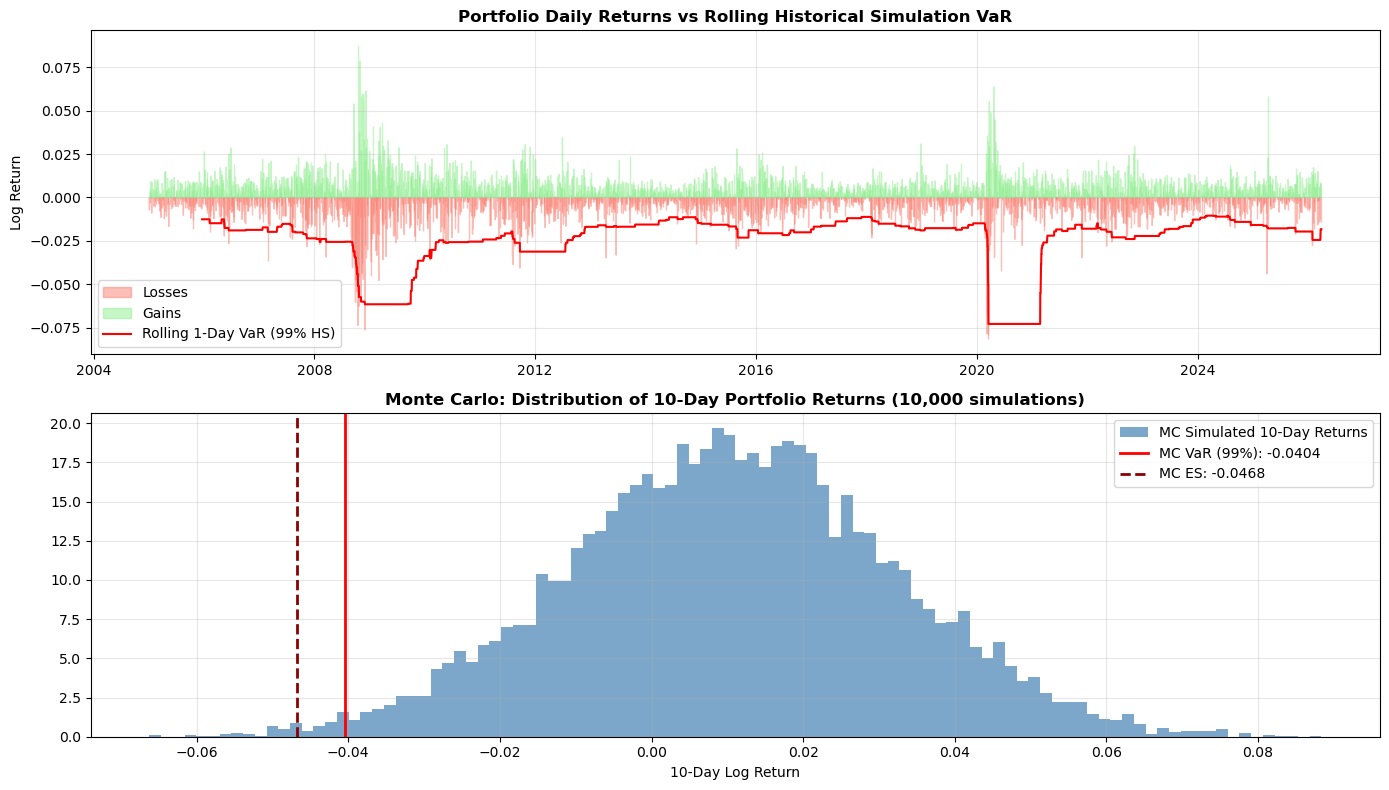


 VaR estimates saved.


In [7]:
# ── Visualization: Rolling 1-Day VaR (Historical) ────────────────────────────
rolling_hs_var = portfolio_returns.rolling(LOOKBACK_DAYS).quantile(ALPHA)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Returns vs VaR
ax = axes[0]
ax.fill_between(portfolio_returns.index, portfolio_returns.values, 0,
                where=(portfolio_returns < 0), color='salmon', alpha=0.5, label='Losses')
ax.fill_between(portfolio_returns.index, portfolio_returns.values, 0,
                where=(portfolio_returns >= 0), color='lightgreen', alpha=0.5, label='Gains')
ax.plot(rolling_hs_var.index, rolling_hs_var.values, 'r-', linewidth=1.5,
        label=f'Rolling 1-Day VaR ({CONFIDENCE_LEVEL:.0%} HS)')
ax.set_title('Portfolio Daily Returns vs Rolling Historical Simulation VaR', fontweight='bold')
ax.set_ylabel('Log Return')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

# Plot 2: MC distribution
ax2 = axes[1]
sim_dist = mc_results['sim_distribution']
ax2.hist(sim_dist, bins=100, density=True, color='steelblue', alpha=0.7, label='MC Simulated 10-Day Returns')
ax2.axvline(mc_results[f'VaR_{HOLDING_PERIOD}d'], color='red', lw=2,
            label=f'MC VaR ({CONFIDENCE_LEVEL:.0%}): {mc_results[f"VaR_{HOLDING_PERIOD}d"]:.4f}')
ax2.axvline(mc_results[f'ES_{HOLDING_PERIOD}d'], color='darkred', lw=2, linestyle='--',
            label=f'MC ES: {mc_results[f"ES_{HOLDING_PERIOD}d"]:.4f}')
ax2.set_title(f'Monte Carlo: Distribution of {HOLDING_PERIOD}-Day Portfolio Returns ({MC_SIMULATIONS:,} simulations)', fontweight='bold')
ax2.set_xlabel('10-Day Log Return')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig5_var_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save VaR estimates
var_summary = pd.DataFrame({
    'method': ['historical', 'parametric', 'monte_carlo'],
    'var_1d': [hs_results['VaR_1d'], param_results['VaR_1d'], mc_results['VaR_1d']],
    'var_10d': [hs_results[f'VaR_{HOLDING_PERIOD}d'], param_results[f'VaR_{HOLDING_PERIOD}d'],
                mc_results[f'VaR_{HOLDING_PERIOD}d']],
    'es_10d': [hs_results[f'ES_{HOLDING_PERIOD}d'], param_results[f'ES_{HOLDING_PERIOD}d'],
               mc_results[f'ES_{HOLDING_PERIOD}d']]
})
var_summary.to_csv(os.path.join(DATA_DIR, 'var_estimates.csv'), index=False)
print('\n VaR estimates saved.')